# Data profile & validation setup (IDI synthetic)

Produces slide-ready tables/figures for:
- Dataset overview (row counts, incidence rate, mean and P90 severity)
- Time-split schematic (train vs test)
- Incidence by month
- Severity distribution on log scale
- A simple workflow schematic

Date created: 2026-06-05


In [1]:
# --- Common setup ---
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.patches import FancyBboxPatch

from pathlib import Path
from sklearn.preprocessing import OneHotEncoder

pd.set_option("display.max_columns", 200)
np.set_printoptions(suppress=True)

pd.set_option("display.max_columns", 200)
np.set_printoptions(suppress=True)

def make_ohe_dense(drop=None):
    """Dense one-hot encoder compatible across sklearn versions."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop=drop)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False, drop=drop)

def make_ohe_sparse(drop=None):
    """Sparse one-hot encoder compatible across sklearn versions."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True, drop=drop)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True, drop=drop)


In [2]:
# Paths

PROJECT_ROOT = Path("C:/Users/ca/OneDrive/Documents/@ CA/@ PROJECTS/FFNNs/IDS 2026")

EXPOSURE_CSV = f"{PROJECT_ROOT}/data/raw/idi_exposure_synth_v1.csv"
CLAIMS_CSV   = f"{PROJECT_ROOT}/data/raw/idi_claims_synth_v1.csv"

OUT_DIR = "outputs_figures"
os.makedirs(OUT_DIR, exist_ok=True)

EXPOSURE_CSV, CLAIMS_CSV, OUT_DIR

('C:\\Users\\ca\\OneDrive\\Documents\\@ CA\\@ PROJECTS\\FFNNs\\IDS 2026/data/raw/idi_exposure_synth_v1.csv',
 'C:\\Users\\ca\\OneDrive\\Documents\\@ CA\\@ PROJECTS\\FFNNs\\IDS 2026/data/raw/idi_claims_synth_v1.csv',
 'outputs_figures')

In [3]:
# --- Load data ---
expo_df = pd.read_csv(EXPOSURE_CSV, parse_dates=["month_start"])
claims_df = pd.read_csv(CLAIMS_CSV, parse_dates=["month_start"])

print("Exposure rows:", len(expo_df), "| columns:", expo_df.shape[1])
print("Claims rows  :", len(claims_df), "| columns:", claims_df.shape[1])

# quick schema checks
for c in ["life_id","month_start","exposure_months","onset"]:
    assert c in expo_df.columns, f"Missing in exposure: {c}"
for c in ["claim_id","month_start","total_paid_ultimate"]:
    assert c in claims_df.columns, f"Missing in claims: {c}"


Exposure rows: 144000 | columns: 35
Claims rows  : 1565 | columns: 37


In [4]:
# Sanity check table

summary = {
    "Exposure rows": int(len(expo_df)),
    "Claims rows": int(len(claims_df)),
    "Date min": str(expo_df["month_start"].min().date()),
    "Date max": str(expo_df["month_start"].max().date()),
    "Monthly onset rate": float(expo_df["onset"].mean()),
    "Mean claim cost (CHF)": float(claims_df["total_paid_ultimate"].mean()),
    "P90 claim cost (CHF)": float(np.quantile(claims_df["total_paid_ultimate"], 0.90)),
}

def fmt(metric, v):
    if metric in {"Exposure rows", "Claims rows"}:
        return f"{int(v):,}"                
    if metric == "Monthly onset rate":
        return f"{v:.6f}"
    if "CHF" in metric:
        return f"{v:,.0f}"
    return str(v)

rows = [(k, fmt(k, v)) for k, v in summary.items()]

w1 = max(len("Metric"), max(len(m) for m, _ in rows))
w2 = max(len("Value"),  max(len(val) for _, val in rows))

print(f"{'Metric':<{w1}}  {'Value':>{w2}}")
for m, val in rows:
    print(f"{m:<{w1}}  {val:>{w2}}")


Metric                      Value
Exposure rows             144,000
Claims rows                 1,565
Date min               2022-01-01
Date max               2023-12-01
Monthly onset rate       0.010868
Mean claim cost (CHF)     101,625
P90 claim cost (CHF)      160,396


In [5]:
# --- Time split (last N months as test) ---
N_TEST_MONTHS = 6
months_sorted = np.sort(expo_df["month_start"].unique())
cutoff = months_sorted[-N_TEST_MONTHS]

train_expo = expo_df[expo_df["month_start"] < cutoff].copy()
test_expo  = expo_df[expo_df["month_start"] >= cutoff].copy()
train_claims = claims_df[claims_df["month_start"] < cutoff].copy()
test_claims  = claims_df[claims_df["month_start"] >= cutoff].copy()

print("Test starts:", pd.to_datetime(cutoff).date())
print("Train exposure:", len(train_expo), " Test exposure:", len(test_expo))
print("Train claims:", len(train_claims), " Test claims:", len(test_claims))
assert len(train_claims) > 0 and len(test_claims) > 0, "Train/test claims split is empty."


Test starts: 2023-07-01
Train exposure: 108000  Test exposure: 36000
Train claims: 1181  Test claims: 384


'outputs_figures\\incidence_by_month.svg'

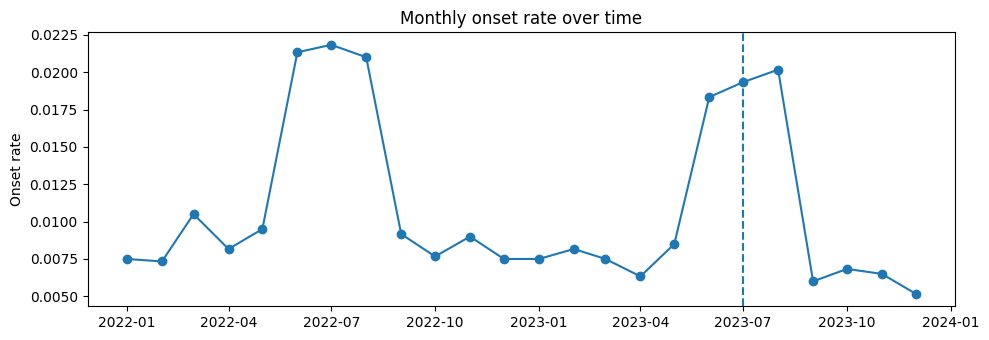

In [6]:
# --- Plot: incidence rate by month ---
inc_by_month = expo_df.groupby("month_start")["onset"].mean().reset_index()
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(inc_by_month["month_start"], inc_by_month["onset"], marker="o")
ax.axvline(pd.to_datetime(cutoff), linestyle="--")
ax.set_title("Monthly onset rate over time")
ax.set_ylabel("Onset rate")
fig.tight_layout()
fig_path = os.path.join(OUT_DIR, "incidence_by_month.svg")
fig.savefig(fig_path, dpi=300)
fig_path


'outputs_figures\\severity_log1p_hist.svg'

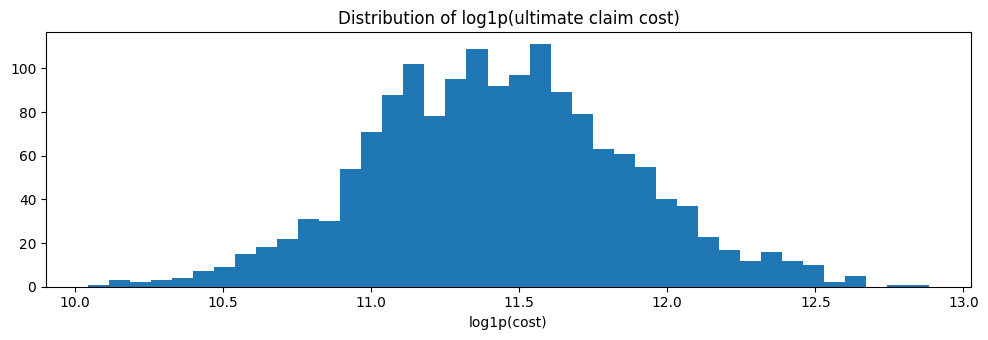

In [7]:
# --- Plot: severity distribution on log scale (claims only) ---
y = claims_df["total_paid_ultimate"].astype(float).values
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.hist(np.log1p(y), bins=40)
ax.set_title("Distribution of log1p(ultimate claim cost)")
ax.set_xlabel("log1p(cost)")
fig.tight_layout()
fig_path = os.path.join(OUT_DIR, "severity_log1p_hist.svg")
fig.savefig(fig_path, dpi=300)
fig_path


'outputs_figures\\workflow_schematic_vertical.svg'

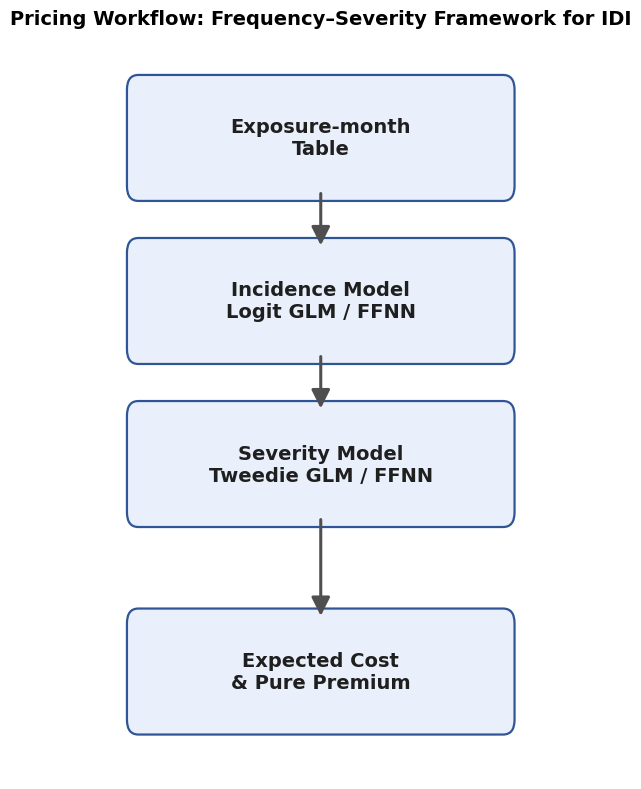

In [11]:
# Vertical workflow schematic

fig, ax = plt.subplots(figsize=(6, 8))
ax.axis("off")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Box settings
box_x = 0.18
box_w = 0.64
box_h = 0.13

boxes = [
    {"y": 0.80, "label": "Exposure-month\nTable"},
    {"y": 0.58, "label": "Incidence Model\nLogit GLM / FFNN"},
    {"y": 0.36, "label": "Severity Model\nTweedie GLM / FFNN"},
    {"y": 0.08, "label": "Expected Cost\n& Pure Premium"},
]

# Draw boxes
for b in boxes:
    patch = FancyBboxPatch(
        (box_x, b["y"]),
        box_w,
        box_h,
        boxstyle="round,pad=0.02,rounding_size=0.02",
        linewidth=1.6,
        edgecolor="#2F5597",
        facecolor="#EAF0FB"
    )
    ax.add_patch(patch)
    ax.text(
        box_x + box_w / 2,
        b["y"] + box_h / 2,
        b["label"],
        ha="center",
        va="center",
        fontsize=14,
        fontweight="semibold",
        color="#1F1F1F"
    )

for i in range(len(boxes) - 1):
    x_mid = box_x + box_w / 2
    y_start = boxes[i]["y"]
    y_end = boxes[i + 1]["y"] + box_h

    ax.annotate(
        "",
        xy=(x_mid, y_end + 0.01),
        xytext=(x_mid, y_start - 0.01),
        arrowprops=dict(
            arrowstyle="-|>",
            lw=2.2,
            color="#4F4F4F",
            mutation_scale=28,
            shrinkA=0,
            shrinkB=0
        )
    )

# Title
ax.set_title(
    "Pricing Workflow: Frequency–Severity Framework for IDI",
    fontsize=14,
    fontweight="bold",
    pad=10
)

fig.tight_layout()
fig_path = os.path.join(OUT_DIR, "workflow_schematic_vertical.svg")
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
fig_path

'outputs_figures\\lift_vs_governance_2x2.svg'

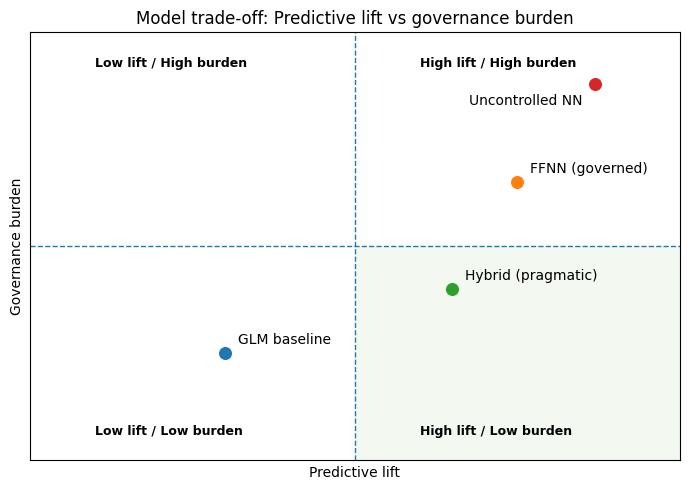

In [9]:
# 2x2: Predictive lift vs Governance burden (Motivation slide asset)

from matplotlib.patches import Rectangle


fig, ax = plt.subplots(figsize=(7, 5))

# Axes: abstract 0–10 scale
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_xlabel("Predictive lift")
ax.set_ylabel("Governance burden")

ax.set_xticks([])
ax.set_yticks([])

preferred_quad = Rectangle(
    (5, 0),   # lower-left corner
    5,        # width
    5,        # height
    facecolor="#DFF0D8",
    edgecolor="none",
    alpha=0.35,
    zorder=0
)
ax.add_patch(preferred_quad)

points = [
    ("GLM baseline", 3.0, 2.5),
    ("FFNN (governed)", 7.5, 6.5),
    ("Hybrid (pragmatic)", 6.5, 4.0),
    ("Uncontrolled NN", 8.7, 8.8),
]

for label, x, y in points:
    ax.scatter([x], [y], s=70)
    
    if label == "Uncontrolled NN":
        # move label inside the matrix
        ax.text(x - 0.2, y - 0.25, label, fontsize=10, ha="right", va="top")
    else:
        ax.text(x + 0.2, y + 0.15, label, fontsize=10, ha="left", va="bottom")

# Quadrant guides
ax.axvline(5, linestyle="--", linewidth=1)
ax.axhline(5, linestyle="--", linewidth=1)

# Quadrant annotations
ax.text(1.0, 9.2, "Low lift / High burden", fontsize=9, fontweight="bold")
ax.text(6.0, 9.2, "High lift / High burden", fontsize=9, fontweight="bold")
ax.text(1.0, 0.6, "Low lift / Low burden", fontsize=9, fontweight="bold")
ax.text(6.0, 0.6, "High lift / Low burden", fontsize=9, fontweight="bold")

ax.set_title("Model trade-off: Predictive lift vs governance burden")
fig.tight_layout()

svg_path = os.path.join(OUT_DIR, "lift_vs_governance_2x2.svg")
fig.savefig(svg_path, dpi=300, bbox_inches="tight")

svg_path

('outputs_figures\\architecture_glm_vs_ffnn.png',
 'outputs_figures\\architecture_glm_vs_ffnn.svg')

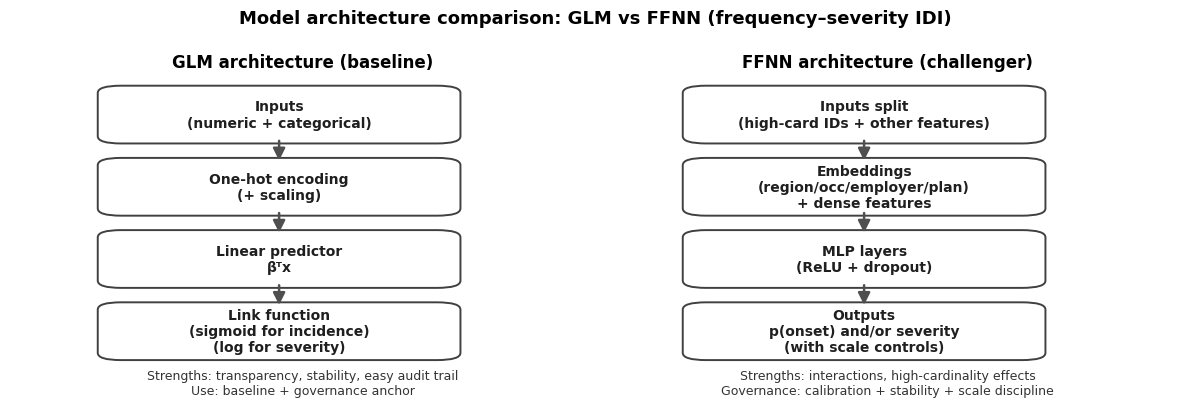

In [10]:
# Model architecture schematic (GLM vs FFNN)

OUT_DIR = globals().get("OUT_DIR", "outputs_figures")
os.makedirs(OUT_DIR, exist_ok=True)

fig, ax = plt.subplots(figsize=(12, 4.2))
ax.axis("off")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

def add_box(x, y, w, h, text, fontsize=10, weight="semibold"):
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.015,rounding_size=0.02",
        linewidth=1.4, edgecolor="#404040", facecolor="white"
    )
    ax.add_patch(patch)
    ax.text(x + w/2, y + h/2, text, ha="center", va="center",
            fontsize=fontsize, fontweight=weight, color="#1F1F1F")

def arrow(x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", lw=1.8, color="#4F4F4F", mutation_scale=18))

# Column headers
ax.text(0.25, 0.93, "GLM architecture (baseline)", ha="center", va="center", fontsize=12, fontweight="bold")
ax.text(0.75, 0.93, "FFNN architecture (challenger)", ha="center", va="center", fontsize=12, fontweight="bold")

# --- GLM column (left) ---
xL = 0.06
w = 0.34
box_w = 0.28
box_h = 0.13

add_box(xL + 0.03, 0.72, box_w, box_h, "Inputs\n(numeric + categorical)")
add_box(xL + 0.03, 0.52, box_w, box_h, "One-hot encoding\n(+ scaling)")
add_box(xL + 0.03, 0.32, box_w, box_h, "Linear predictor\nβᵀx")
add_box(xL + 0.03, 0.12, box_w, box_h, "Link function\n(sigmoid for incidence)\n(log for severity)")

arrow(xL + 0.17, 0.72, xL + 0.17, 0.65)
arrow(xL + 0.17, 0.52, xL + 0.17, 0.45)
arrow(xL + 0.17, 0.32, xL + 0.17, 0.25)

# Notes (GLM)
ax.text(0.25, 0.04,
        "Strengths: transparency, stability, easy audit trail\nUse: baseline + governance anchor",
        ha="center", va="center", fontsize=9, color="#333333")

# --- FFNN column (right) ---
xR = 0.56

add_box(xR + 0.03, 0.72, box_w, box_h, "Inputs split\n(high-card IDs + other features)")
add_box(xR + 0.03, 0.52, box_w, box_h, "Embeddings\n(region/occ/employer/plan)\n+ dense features")
add_box(xR + 0.03, 0.32, box_w, box_h, "MLP layers\n(ReLU + dropout)")
add_box(xR + 0.03, 0.12, box_w, box_h, "Outputs\np(onset) and/or severity\n(with scale controls)")

arrow(xR + 0.17, 0.72, xR + 0.17, 0.65)
arrow(xR + 0.17, 0.52, xR + 0.17, 0.45)
arrow(xR + 0.17, 0.32, xR + 0.17, 0.25)

# Notes (FFNN)
ax.text(0.75, 0.04,
        "Strengths: interactions, high-cardinality effects\nGovernance: calibration + stability + scale discipline",
        ha="center", va="center", fontsize=9, color="#333333")

ax.set_title("Model architecture comparison: GLM vs FFNN (frequency–severity IDI)", fontsize=13, fontweight="bold", pad=10)
fig.tight_layout()

png_path = os.path.join(OUT_DIR, "architecture_glm_vs_ffnn.png")
svg_path = os.path.join(OUT_DIR, "architecture_glm_vs_ffnn.svg")
fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(svg_path, dpi=300, bbox_inches="tight")

(png_path, svg_path)